# Early Universe Cosmology Lab: Big Bang Nucleosynthesis (BBN)

AST 3414 - Spring 2026

## Introduction

In this lab you will use **PRyMordial** ([Burns, Tait, & Valli 2023](https://arxiv.org/abs/2307.07061)) to compute the primordial abundances of light elements and generate the classic **Schramm plot** — the defining visualization of BBN.

### What You'll Learn

1. Run the standard BBN calculation in the first 3 minutes and interpret the output.
2. Explore how input physics (neutron lifetime, nuclear rates) shifts the predictions.
3. Sweep the baryon-to-photon ratio $\eta_b$ and produce the Schramm plot.
4. Compare theory to observation and identify the cosmological lithium problem.

---

This is a Pair Programming Lab - Please work together with all members looking at the same copy of the code on one computer. One member will be the Driver who controls the keyboard. The others will be the Navigator(s) who reviews code and think strategically, giving instructions to the Drive.

Every 20-30 minutes an announcement will be made to switch roles.

---
### Setup

In [1]:
!pip install numpy scipy numba

In [2]:
# this is included because there is a weird path dependence in PRyMoridal
!rm -rf *
!rm -rf .*
!git clone https://github.com/vallima/PRyMordial.git .

rm: refusing to remove '.' or '..' directory: skipping '.'
rm: refusing to remove '.' or '..' directory: skipping '..'
Cloning into '.'...
remote: Enumerating objects: 241, done.
remote: Counting objects: 100% (133/133), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 241 (delta 79), reused 125 (delta 76), pack-reused 108 (from 1)
Receiving objects: 100% (241/241), 1.46 MiB | 6.15 MiB/s, done.
Resolving deltas: 100% (118/118), done.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import PRyM.PRyM_main as PRyMmain
import PRyM.PRyM_init as PRyMini

---
### Part 1. Standard BBN Calculation

The first call takes ~20 s (Numba compilation + thermodynamic background). `PRyMresults()` returns an array of 8 quantities:

| Index | Quantity | Units / scaling |
|-------|---------|----------------|
| 0 | $N_{\rm eff}$ | — |
| 1 | $\Omega_\nu h^2$ (rel.) | $\times 10^6$ |
| 2 | $\sum m_\nu / (\Omega_\nu h^2)$ | eV |
| 3 | $Y_P$ (CMB) | — |
| 4 | $Y_P$ (BBN) | — |
| 5 | D/H | $\times 10^5$ |
| 6 | $^3$He/H | $\times 10^5$ |
| 7 | $^7$Li/H | $\times 10^{10}$ |

In [4]:
# "Hello, World!" of PRyMordial
%time myPRyM = PRyMmain.PRyMclass()
results = myPRyM.PRyMresults()

print("Standard BBN predictions:")
print(f"  N_eff           = {results[0]:.4f}")
print(f"  Y_P (BBN)       = {results[4]:.5f}")
print(f"  D/H             = {results[5]:.3f} x 10^-5")
print(f"  3He/H           = {results[6]:.3f} x 10^-5")
print(f"  7Li/H           = {results[7]:.3f} x 10^-10")

CPU times: user 22.7 s, sys: 258 ms, total: 22.9 s
Wall time: 26.6 s
Standard BBN predictions (PDG inputs):
  N_eff           = 3.0444
  Y_P (BBN)       = 0.24689
  D/H             = 2.454 x 10^-5
  3He/H           = 1.041 x 10^-5
  7Li/H           = 5.439 x 10^-10


In [5]:
# You can also call individual observables:
print(f"Y_P  = {myPRyM.YPBBN():.6f}")
print(f"D/H  = {myPRyM.DoH():.4e}")
print(f"7Li/H = {myPRyM.Li7oH():.4e}")

Y_P  = 0.246891
D/H  = 2.4545e-05
7Li/H = 5.4387e-10


**Compare to observations:**
- $Y_P \approx 0.245 \pm 0.003$ (extragalactic HII regions)
- D/H $\approx (2.547 \pm 0.025) \times 10^{-5}$ (quasar absorption systems)
- $^7$Li/H $\approx (1.6 \pm 0.3) \times 10^{-10}$ (metal-poor halo stars)

---
### Part 2: Changing the Input Physics

PRyMordial lets you modify physical inputs and see how predictions shift.

In [6]:
# Change the neutron lifetime
PRyMini.tau_n = 879  # s (slightly above PDG central value)
myPRyM_newtau = PRyMmain.PRyMclass()
print("With tau_n = 879 s:")
print(f"  Y_P  = {myPRyM_newtau.YPBBN():.6f}  (was {myPRyM.YPBBN():.6f})")
print(f"  D/H  = {myPRyM_newtau.DoH():.4e}  (was {myPRyM.DoH():.4e})")

With tau_n = 879 s:
  Y_P  = 0.247008  (was 0.246891)
  D/H  = 2.4567e-05  (was 2.4545e-05)


In [7]:
# Switch to NACRE-II nuclear rate compilation
PRyMini.tau_n = 878.4  # restore PDG 2023 value
PRyMini.nacreii_flag = True
PRyMini.ReloadKeyRates()
myPRyM_nacreii = PRyMmain.PRyMclass()
print("With NACRE-II rates:")
print(f"  D/H   = {myPRyM_nacreii.DoH():.4e}  (default: {myPRyM.DoH():.4e})")
print(f"  7Li/H = {myPRyM_nacreii.Li7oH():.4e}  (default: {myPRyM.Li7oH():.4e})")

With NACRE-II rates:
  D/H   = 2.5272e-05  (default: 2.4545e-05)
  7Li/H = 5.2747e-10  (default: 5.4387e-10)


**Question:** Which abundances are most sensitive to the nuclear rate compilation? Why might D/H shift more than $Y_P$?

# YOUR ANSWER HERE

---
### Part 3: The Schramm Plot

The [Schramm plot](https://commons.wikimedia.org/wiki/File:Schramm_plot_BBN_review_2019.png) shows predicted primordial abundances as a function of $\eta_b$. By overlaying observational constraints, we can verify that *all* abundances point to a single baryon density — except lithium.

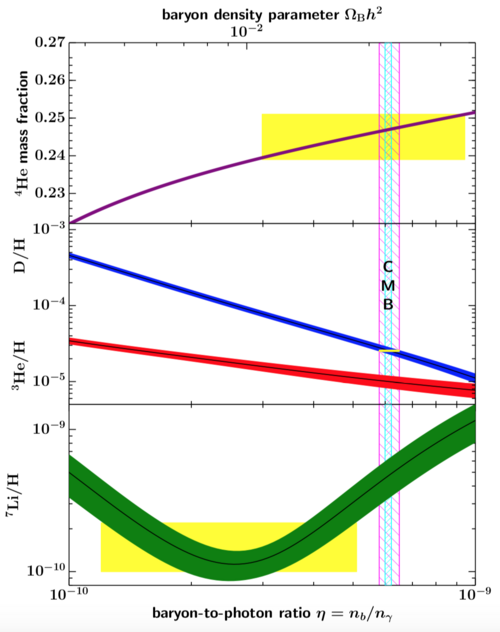

First, we set up for a fast sweep. Changing $\eta_b$ doesn't require recomputing the thermodynamic background or $n \leftrightarrow p$ rates, so we disable those flags to speed things up.

In [8]:
# Recompute background once with clean settings, then cache it
PRyMini.tau_n = 878.4
PRyMini.nacreii_flag = True
PRyMini.ReloadKeyRates()
PRyMini.compute_bckg_flag = True
PRyMini.save_bckg_flag = True
PRyMini.compute_nTOp_flag = True
PRyMini.save_nTOp_flag = True
PRyMini.smallnet_flag = True

# First run: computes and saves background + n<->p rates
_ = PRyMmain.PRyMclass().PRyMresults()
print("Background computed and cached.")

Background computed and cached.


In [9]:
# Now disable recomputation — each eta_b point will take ~3 s instead of ~20 s
PRyMini.compute_bckg_flag = False
PRyMini.save_bckg_flag = False
PRyMini.compute_nTOp_flag = False
PRyMini.save_nTOp_flag = False

# Sweep eta_b
npoints = 20
etabvec = np.logspace(-10, -9, npoints)
YP_vec, DoH_vec, He3oH_vec, Li7oH_vec = np.zeros((4, npoints))

print(f"Running BBN for {npoints} values of eta_b...")
for i in range(npoints):
    PRyMini.eta0b = etabvec[i]
    YP_vec[i], DoH_vec[i], He3oH_vec[i], Li7oH_vec[i] = PRyMmain.PRyMclass().PRyMresults()[4:8]
    if (i + 1) % 5 == 0:
        print(f"  {i+1}/{npoints} done")

print("Sweep complete!")

Running BBN for 20 values of eta_b...
  5/20 done
  10/20 done
  15/20 done
  20/20 done
Sweep complete!


Now it's up to you to write the code to make the plot! Your x-axis should be the baryon-to-photon ratio $\eta$, and your y-axis will be four different variables, listed below in some code to help get you started. Review past activities if you need help remembering how to write code for plotting. There is also code to give you the constraints from observations (cyan line for CMB, yellow boxes for primordial stellar abundances).

In [12]:
eta10 = etabvec * 1e10  # plot in units of eta_b x 10^10

# CMB-determined value (Planck 2018)
eta_cmb = PRyMini.Omegabh2_to_eta0b * 0.02230 * 1e10
eta_cmb_error = 0.09

# YOUR CODE GOES HERE

# --- Y_P (4He mass fraction) ---
# Between 0.2370 and 0.2530 from Aver, et al. 2015

# --- D/H ---
# Between 2.52 and 2.57 from Cooke, et al. 2018

# --- 3He/H ---

# --- 7Li/H ---
# Between 1.3 and 1.9 from Sbordone, et al. 2010


### Interpreting the Schramm Plot

Be sure to include vertical band to mark $\eta_b$ as measured independently by the CMB (Planck 2018), and horizontal shaded regions are observational measurements of each abundance.

**Question 2:**
Why does $Y_P$ *increase* with $\eta_b$ while D/H *decreases*? Think about what a higher baryon density means for nuclear reaction rates.

**Question 3:** At the CMB value of $\eta_b$, the $Y_P$ and D/H predictions land squarely in the observed bands. What about $^7$Li?

**Question 4:** This concordance at a *single* $\eta_b$ — determined independently by the CMB — is one of the great triumphs of the Big Bang model. In your own words, why is this so compelling?

### YOUR ANSWERS HERE

`PRyMordial` is capable of state-of-the-art analyses that explore physics beyond the standard model (perhaps as a **computational essay**). Several theories can be simulated which have been proposed to explain the discrepant $^7$Li abundances. To learn more, I recommend reading the paper ([Burns, Tait, & Valli 2023](https://arxiv.org/abs/2307.07061)), or watching [this talk](https://www.youtube.com/watch?v=lh1-WT9qpQ0).
Note that the code was developed as the basis for Dr. Burns' PhD thesis at UC Irvine.

